In [26]:
import numpy as np
import pandas as pd
import galpy
import astropy
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [27]:
#NASA Exoplanet Archive
nasa = pd.read_csv("NASA exoplanet Archive (filtered Columns) 1 (Degrees).csv",
                   skiprows=30)
nasa = nasa[nasa["gaia_dr3_id"].notna()].copy()
nasa["gaia_id_clean"] = (nasa["gaia_dr3_id"]
                          .astype(str)
                          .str.replace("Gaia DR3 ", "", regex=False)
                          .str.strip())

# Drop duplicate Gaia IDs - keep one row per host star
nasa = nasa.drop_duplicates(subset="gaia_id_clean", keep="first")
nasa_ids = set(nasa["gaia_id_clean"])

#APOGEE DR17
apogee = pd.read_csv("apogee_new.csv")
apogee["gaia_id_clean"] = apogee["GAIAEDR3_SOURCE_ID"].astype(str).str.strip()

print(f"NASA exoplanet hosts (with Gaia ID): {len(nasa):,}")
print(f"APOGEE DR17 stars:                   {len(apogee):,}")


#Quick inspection sample
apogee.head(200).to_csv("apogee_sample_200.csv", index=False)
print("\nColumns in APOGEE file:")
print(list(apogee.columns))

NASA exoplanet hosts (with Gaia ID): 4,205
APOGEE DR17 stars:                   554,738

Columns in APOGEE file:
['APOGEE_ID', 'GAIAEDR3_SOURCE_ID', 'RA', 'DEC', 'GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PMRA', 'GAIAEDR3_PMRA_ERROR', 'GAIAEDR3_PMDEC', 'GAIAEDR3_PMDEC_ERROR', 'VHELIO_AVG', 'SNR', 'STARFLAG', 'ASPCAPFLAG', 'FE_H', 'FE_H_ERR', 'ALPHA_M', 'ALPHA_M_ERR', 'MG_FE', 'MG_FE_ERR', 'AL_FE', 'AL_FE_ERR', 'MN_FE', 'MN_FE_ERR', 'SI_FE', 'SI_FE_ERR', 'CA_FE', 'CA_FE_ERR', 'TI_FE', 'TI_FE_ERR', 'TEFF', 'TEFF_ERR', 'LOGG', 'LOGG_ERR', 'M_H', 'M_H_ERR', 'NVISITS', 'gaia_id_clean']


In [28]:
apogee = (apogee
           .sort_values("SNR", ascending=False)
           .drop_duplicates(subset="gaia_id_clean", keep="first"))

print(f"\nAPOGEE after deduplication: {len(apogee):,} unique stars")


APOGEE after deduplication: 554,724 unique stars


In [29]:
nasa_apogee = nasa.merge(
    apogee,
    on="gaia_id_clean",
    how="inner"
)
print(f"Combined NASA + APOGEE: {len(nasa_apogee):,} rows")

# Standard APOGEE alpha elements relative to Fe
alpha_cols     = ['MG_FE', 'SI_FE', 'CA_FE', 'TI_FE']
alpha_err_cols = ['MG_FE_ERR', 'SI_FE_ERR', 'CA_FE_ERR', 'TI_FE_ERR']

# Compute nanmean across the 4 elements row-wise
nasa_apogee['ALPHA_FE']     = nasa_apogee[alpha_cols].mean(axis=1)
nasa_apogee['ALPHA_FE']    = nasa_apogee[alpha_cols].mean(axis=1)

# Same for errors
nasa_apogee['ALPHA_FE_ERR']  = nasa_apogee[alpha_err_cols].mean(axis=1)

apogee['ALPHA_FE']     = apogee[alpha_cols].mean(axis=1)
apogee['ALPHA_FE']    = apogee[alpha_cols].mean(axis=1)

# Same for errors
apogee['ALPHA_FE_ERR']  = apogee[alpha_err_cols].mean(axis=1)

# Save full APOGEE catalogue (for plot backgrounds)
apogee.to_csv("apogee_full_catalog.csv", index=False)
print("Saved apogee_full_catalog.csv")

# Save matched NASA + APOGEE file
nasa_apogee.to_csv("exoplanet_hosts_apogee_NASA_matched.csv", index=False)
print("Saved exoplanet_hosts_apogee_NASA_matched.csv")


Combined NASA + APOGEE: 1,030 rows
Saved apogee_full_catalog.csv
Saved exoplanet_hosts_apogee_NASA_matched.csv


In [30]:

# Compute parallax fractional error
nasa_apogee["plx_frac_err"] = (
    nasa_apogee["GAIAEDR3_PARALLAX_ERROR"] / nasa_apogee["GAIAEDR3_PARALLAX"]
)

# Quality mask (NaN rows pass through rather than being dropped)
clean_hosts = nasa_apogee[
    (nasa_apogee["SNR"].isna()          | (nasa_apogee["SNR"]          >= 30))   &
    (nasa_apogee["STARFLAG"].isna()     | (nasa_apogee["STARFLAG"]     == 0))    &
    (nasa_apogee["TEFF"].isna()         | (nasa_apogee["TEFF"].between(3500, 5500))) &
    (nasa_apogee["LOGG"].isna()         | (nasa_apogee["LOGG"]         <=4.8))  &
    (nasa_apogee["plx_frac_err"].isna() | (nasa_apogee["plx_frac_err"] <= 0.20))
].copy()

print(f"After quality cuts (hosts): {len(clean_hosts):,} rows")
print(f"Retention: {100 * len(clean_hosts) / len(nasa_apogee):.1f}%")

# Apply same cuts to full APOGEE catalogue (survey background for plots)
apogee_all = pd.read_csv("apogee_full_catalog.csv")
apogee_all["plx_frac_err"] = (
    apogee_all["GAIAEDR3_PARALLAX_ERROR"] / apogee_all["GAIAEDR3_PARALLAX"]
)

apogee_clean = apogee_all[
    (apogee_all["SNR"].isna()      | (apogee_all["SNR"]      >= 300))  &
    (apogee_all["STARFLAG"].isna() | (apogee_all["STARFLAG"] == 0))   &
    (apogee_all["ASPCAPFLAG"].isna()| (apogee_all["ASPCAPFLAG"] == 0)) &
    (apogee_all["LOGG"].isna()         | (apogee_all["LOGG"]         <=4.8))  &
    (apogee_all["TEFF"].isna()     | (apogee_all["TEFF"].between(3500, 5500)))
].copy()

print(f"\nFull APOGEE after quality cuts: {len(apogee_clean):,} rows")
print(f"Retention: {100 * len(apogee_clean) / len(apogee_all):.1f}%")

After quality cuts (hosts): 158 rows
Retention: 15.3%

Full APOGEE after quality cuts: 44,598 rows
Retention: 8.0%


In [31]:
# Select stars with valid RV and positive parallax
orbit_sample = clean_hosts[
    clean_hosts["VHELIO_AVG"].notna() &
    (clean_hosts["GAIAEDR3_PARALLAX"] > 0)
].copy().reset_index(drop=True)

n = len(orbit_sample)
print(f"Stars with valid RV & parallax: {n}")

# Initialise output arrays
v_x_galcen     = np.full(n, np.nan)
v_y_galcen     = np.full(n, np.nan)
v_z_galcen     = np.full(n, np.nan)
v_total_galcen = np.full(n, np.nan)
Lz             = np.full(n, np.nan)
ecc            = np.full(n, np.nan)
E              = np.full(n, np.nan)
X_galcen       = np.full(n, np.nan)
Y_galcen       = np.full(n, np.nan)
Z_galcen       = np.full(n, np.nan)

for i in range(n):
    try:
        o = Orbit(
    [
        orbit_sample["RA"].iloc[i],
        orbit_sample["DEC"].iloc[i],
        1.0 / orbit_sample["GAIAEDR3_PARALLAX"].iloc[i],
        orbit_sample["GAIAEDR3_PMRA"].iloc[i],  
        orbit_sample["GAIAEDR3_PMDEC"].iloc[i],
        orbit_sample["VHELIO_AVG"].iloc[i],
    ],
    radec=True, solarmotion="schoenrich", ro=8.0, vo=220,
        )
        v_x_galcen[i]     = o.vx(use_physical=True)
        v_y_galcen[i]     = o.vy(use_physical=True)
        v_z_galcen[i]     = o.vz(use_physical=True)
        v_total_galcen[i] = np.sqrt(v_x_galcen[i]**2 + v_y_galcen[i]**2 + v_z_galcen[i]**2)
        Lz[i]             = o.Lz(use_physical=True)
        ecc[i]            = o.e(use_physical=True, pot=MWPotential2014, analytic=True)
        E[i]              = o.E(use_physical=True, pot=MWPotential2014)
        X_galcen[i]       = o.x(use_physical=True)
        Y_galcen[i]       = o.y(use_physical=True)
        Z_galcen[i]       = o.z(use_physical=True)
    except Exception as e:
        print(f"Error at star {i}: {e}")

print(f"Orbits computed for {(~np.isnan(Lz)).sum()} / {n} stars")

# Attach orbit columns to orbit_sample
orbit_sample["v_x_galcen"]     = v_x_galcen
orbit_sample["v_y_galcen"]     = v_y_galcen
orbit_sample["v_z_galcen"]     = v_z_galcen
orbit_sample["v_total_galcen"] = v_total_galcen
orbit_sample["Lz_orbit"]       = Lz
orbit_sample["e_orbit"]        = ecc
orbit_sample["E_orbit"]        = E
orbit_sample["X_galcen"]       = X_galcen
orbit_sample["Y_galcen"]       = Y_galcen
orbit_sample["Z_galcen"]       = Z_galcen

# Merge orbit columns back into clean_hosts (NaN for stars without valid RV)
orbit_cols = [
    "gaia_id_clean",
    "v_x_galcen", "v_y_galcen", "v_z_galcen", "v_total_galcen",
    "Lz_orbit", "e_orbit", "E_orbit",
    "X_galcen", "Y_galcen", "Z_galcen",
]
clean_hosts = clean_hosts.merge(orbit_sample[orbit_cols], on="gaia_id_clean", how="left")

clean_hosts.to_csv("exoplanet_hosts_apogee_with_orbits.csv", index=False)
print("Saved exoplanet_hosts_apogee_with_orbits.csv")


Stars with valid RV & parallax: 158
Orbits computed for 158 / 158 stars
Saved exoplanet_hosts_apogee_with_orbits.csv


In [32]:
#Chemical Abundances Errors

# Average [Fe/H] uncertainty
print(f"[Fe/H] unc avg:   {clean_hosts['FE_H_ERR'].dropna().mean():.3f} dex")

# Average [alpha/Fe] uncertainty (mean of the 4 element errors)
print(f"[alpha/Fe] unc avg:   {clean_hosts['ALPHA_FE_ERR'].dropna().mean():.3f} dex")

[Fe/H] unc avg:   0.008 dex
[alpha/Fe] unc avg:   0.021 dex


In [33]:
# MONTE CARLO UNCERTAINTIES FOR TOOMRE DIAGRAM ONLY

N_MC = 1000

vygalcen    = np.full(n, np.nan)
vy_err      = np.full(n, np.nan)
vperp       = np.full(n, np.nan)
vperp_err   = np.full(n, np.nan)

for i in range(n):
    try:
        row = orbit_sample.iloc[i]
        vxs, vys, vzs = [], [], []

        plx_samples  = np.random.normal(row['sy_plx'],   row['sy_plxerr1'],   N_MC)
        pmra_samples = np.random.normal(row['sy_pmra'],  row['sy_pmraerr1'],  N_MC)
        pmde_samples = np.random.normal(row['sy_pmdec'], row['sy_pmdecerr1'], N_MC)
        rv_samples   = np.random.normal(row['VHELIO_AVG'],    0.1,    N_MC)

        for j in range(N_MC):
            if plx_samples[j] <= 0:
                continue
            try:
                o = Orbit(
                    [row['RA'], row['DEC'],
                     1.0 / plx_samples[j],
                     pmra_samples[j], pmde_samples[j], rv_samples[j]],
                    radec=True, solarmotion='schoenrich', ro=8.0, vo=220,
                )
                vxs.append(o.vx(use_physical=True))
                vys.append(o.vy(use_physical=True))
                vzs.append(o.vz(use_physical=True))
            except Exception:
                continue

        if len(vys) < 10:
            continue

        # Vy: median + 1-sigma from 16th/84th percentiles
        p16, p50, p84 = np.percentile(vys, [16, 50, 84])
        vygalcen[i] = p50
        vy_err[i]   = (p84 - p16) / 2

        # Vperp = sqrt(Vx^2 + Vz^2): median + uncertainty
        vperp_arr = np.sqrt(np.array(vxs)**2 + np.array(vzs)**2)
        p16, p50, p84 = np.percentile(vperp_arr, [16, 50, 84])
        vperp[i]     = p50
        vperp_err[i] = (p84 - p16) / 2

    except Exception as e:
        print(f"Error at star {i}: {e}")

# Attach to orbit_sample
orbit_sample['vygalcen']  = vygalcen
orbit_sample['vy_err']    = vy_err
orbit_sample['vperp']     = vperp
orbit_sample['vperp_err'] = vperp_err

# Per-survey uncertainty summary
valid = ~np.isnan(vy_err)

print(" APOGEE — Toomre Diagram Kinematic Uncertainties")

print(f"  N stars with valid MC runs : {valid.sum()} / {n}")
print(f"  Median sigma(V_Y)              : {np.nanmedian(vy_err):.3f} km/s")
print(f"  Median sigma(V_perp)           : {np.nanmedian(vperp_err):.3f} km/s")



 APOGEE — Toomre Diagram Kinematic Uncertainties
  N stars with valid MC runs : 156 / 158
  Median sigma(V_Y)              : 0.114 km/s
  Median sigma(V_perp)           : 0.216 km/s


 plot1_alpha_feh_apogee.png


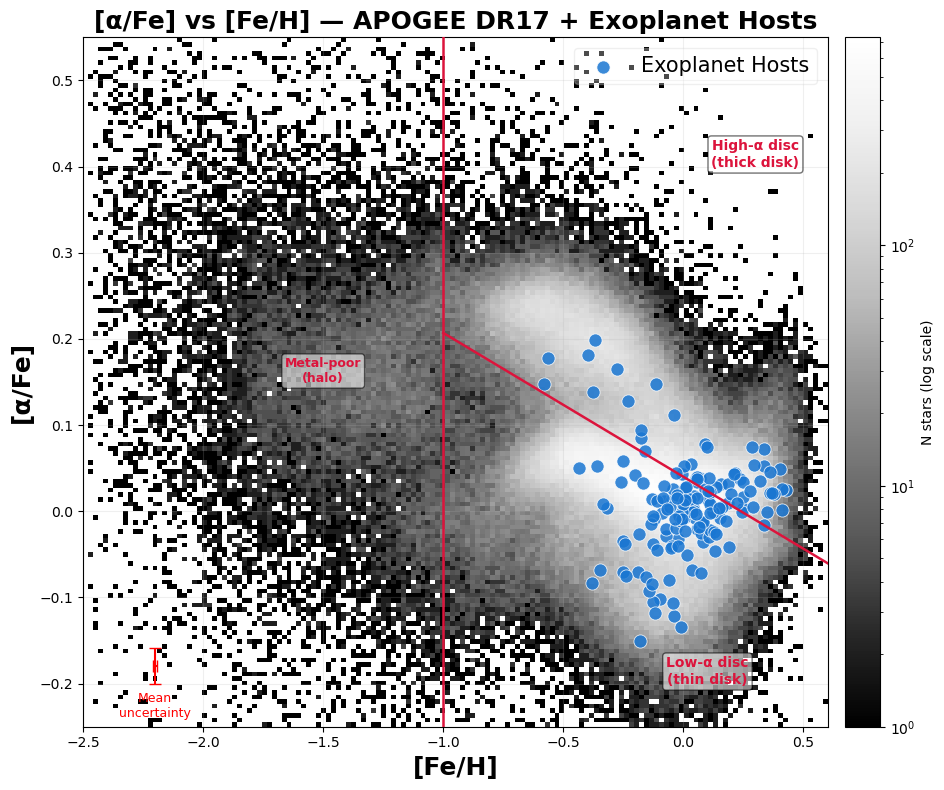

 plot2_toomre_apogee.png


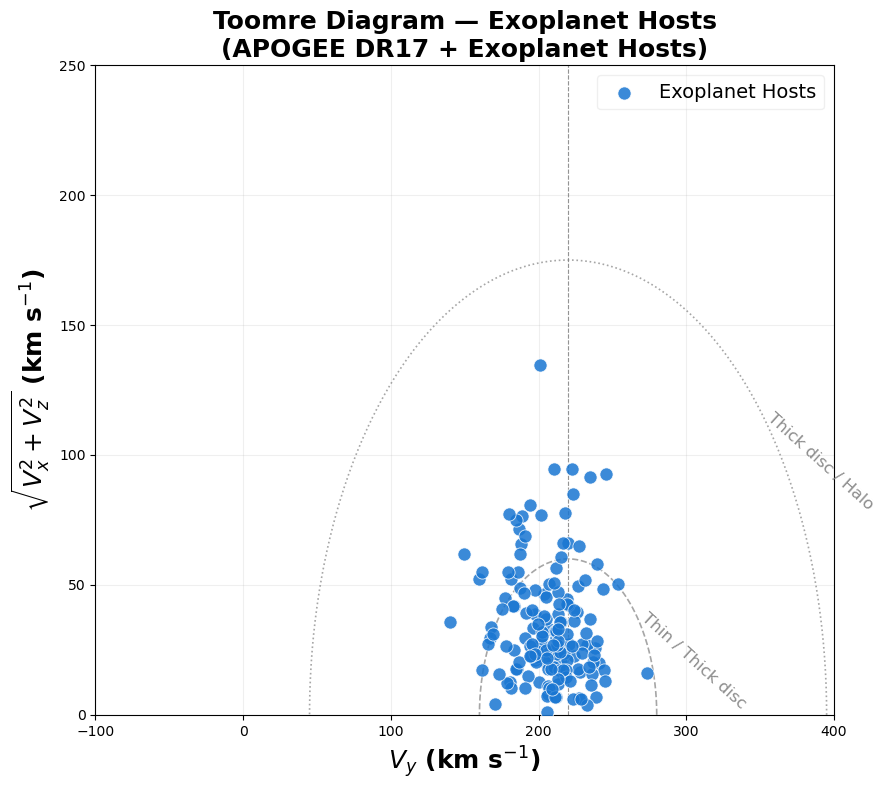

 plot3_galactic_position_apogee.png


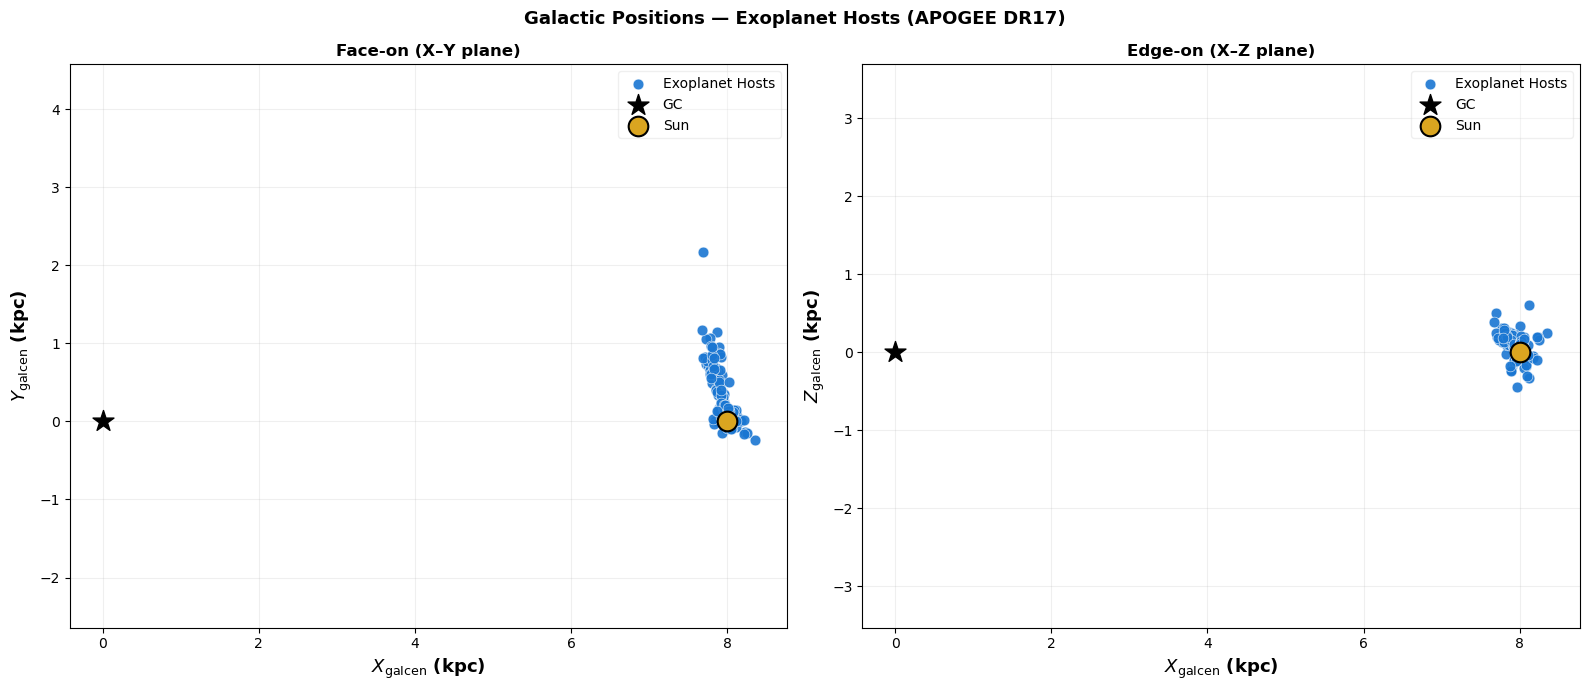

 plot4_mgmn_alfe_apogee.png


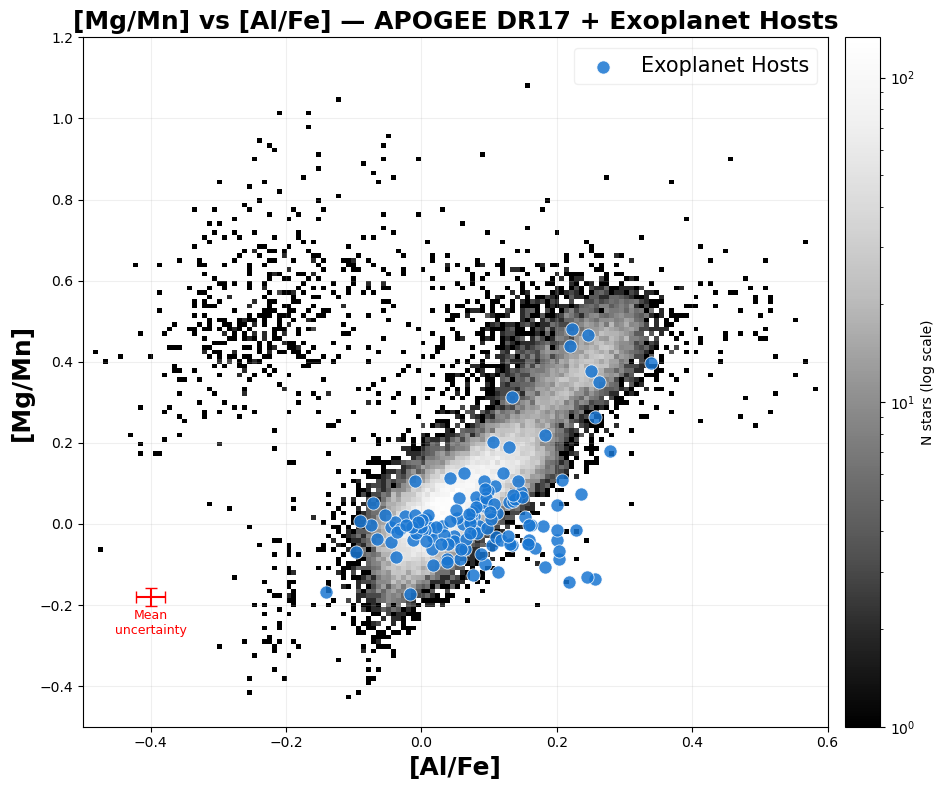

In [34]:

FEH_CUT    = -1.0    # vertical line: metal-poor halo / in-situ boundary
DIAG_SLOPE = -0.167  # slope of high-alpha / low-alpha diagonal
DIAG_INT   =  0.04   # intercept



# PLOT 1 — [alpha/Fe] vs [Fe/H]

bg = apogee.dropna(subset=["FE_H", "ALPHA_FE"])

fig, ax = plt.subplots(figsize=(10, 8))
h = ax.hist2d(bg["FE_H"], bg["ALPHA_FE"],
              bins=150, range=[[-2.5, 0.6], [-0.25, 0.55]],
              cmap="Greys_r", norm=LogNorm(), zorder=1)
plt.colorbar(h[3], ax=ax, label="N stars (log scale)", pad=0.02)

g = clean_hosts.dropna(subset=["FE_H", "ALPHA_FE"])
ax.scatter(g["FE_H"], g["ALPHA_FE"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")

# Representative error cross, bottom-left corner
ax.errorbar(-2.2, -0.18,
            xerr=0.008, yerr=0.021,
            fmt='none', color='red', capsize=4,
            linewidth=1.5, zorder=10)
ax.text(-2.2, -0.21, 'Mean\nuncertainty',
        ha='center', va='top', fontsize=9, color='red')


ax.axvline(FEH_CUT, color="crimson", lw=1.8, ls="-", zorder=6)
feh_diag = np.linspace(FEH_CUT, 0.6, 300)
ax.plot(feh_diag, DIAG_SLOPE * feh_diag + DIAG_INT,
        color="crimson", lw=1.8, ls="-", zorder=6)
        

ax.text(0.3,  0.40, "High-α disc\n(thick disk)",
        color="crimson", fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))
ax.text( 0.1, -0.20, "Low-α disc\n(thin disk)",
        color="crimson", fontsize=10, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))
ax.text(-1.5, 0.15, "Metal-poor\n(halo)",
        color="crimson", fontsize=9,  fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55))

ax.set_xlabel("[Fe/H]",   fontsize=18, fontweight="bold")
ax.set_ylabel("[α/Fe]",    fontsize=18, fontweight="bold")
ax.set_title("[α/Fe] vs [Fe/H] — APOGEE DR17 + Exoplanet Hosts",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot1_alpha_feh_apogee.png", dpi=300, bbox_inches="tight")
print(" plot1_alpha_feh_apogee.png")
plt.show()



# PLOT 2 — Toomre Diagram
# Boundary circles at 60 km/s (thin/thick disc) and 175 km/s (thick disc/halo)

clean_hosts["V_perp"] = np.sqrt(
    clean_hosts["v_x_galcen"]**2 + clean_hosts["v_z_galcen"]**2
)

V_LSR = 220.0  # km/s

fig, ax = plt.subplots(figsize=(9, 8))

g = clean_hosts.dropna(subset=["v_y_galcen", "V_perp"])
ax.scatter(g["v_y_galcen"], g["V_perp"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")

for v_bound, ls, pop_label in [
    ( 60, "--", "Thin / Thick disc"),
    (175, ":",  "Thick disc / Halo"),
]:
    theta = np.linspace(0, np.pi, 300)
    ax.plot(V_LSR + v_bound * np.cos(theta),
            v_bound * np.sin(theta),
            color="grey", ls=ls, lw=1.2, alpha=0.7)
# Place label on the arc at chosen angle
    angle_deg = 42
    angle_rad = np.radians(angle_deg)
    lx = V_LSR + v_bound * np.cos(angle_rad)
    ly = v_bound * np.sin(angle_rad)
    ax.text(lx + 3, ly, pop_label,
            color="grey", fontsize=12, alpha=0.9,
            rotation=-angle_deg,
            ha="left", va="top")

ax.axvline(V_LSR, color="grey", lw=0.8, alpha=0.6, ls="--")
ax.set_ylim(0,250)
ax.set_xlim(-100,400)

ax.axvline(V_LSR, color="grey", lw=0.8, alpha=0.6, ls="--")
ax.set_xlabel(r"$V_y$ (km s$^{-1}$)",
              fontsize=18, fontweight="bold")
ax.set_ylabel(r"$\sqrt{V_x^2 + V_z^2}$ (km s$^{-1}$)",
              fontsize=18, fontweight="bold")
ax.set_title("Toomre Diagram — Exoplanet Hosts\n"
             "(APOGEE DR17 + Exoplanet Hosts)",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=14, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot2_toomre_apogee.png", dpi=300, bbox_inches="tight")
print(" plot2_toomre_apogee.png")
plt.show()



# PLOT 3 — Galactic Positions: face-on (X–Y) and edge-on (X–Z)

hvalid = clean_hosts.dropna(subset=["X_galcen", "Y_galcen", "Z_galcen"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

panels = [
    ("X_galcen", "Y_galcen",
     r"$X_\mathrm{galcen}$ (kpc)", r"$Y_\mathrm{galcen}$ (kpc)",
     "Face-on (X–Y plane)"),
    ("X_galcen", "Z_galcen",
     r"$X_\mathrm{galcen}$ (kpc)", r"$Z_\mathrm{galcen}$ (kpc)",
     "Edge-on (X–Z plane)"),
]

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, panels):
    ax.scatter(hvalid[xcol], hvalid[ycol],
               c="#1976d2", marker="o", s=60,
               edgecolors="white", linewidths=0.4,
               alpha=0.9, zorder=4, label="Exoplanet Hosts")
    ax.scatter(0,   0, c="black",     s=250, marker="*",  zorder=10, label="GC")
    ax.scatter(8.0, 0, c="goldenrod", s=200, marker="o",  zorder=10,
               edgecolors="black", linewidths=1.5, label="Sun")
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold")
    ax.set_title(title,   fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.3)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle("Galactic Positions — Exoplanet Hosts (APOGEE DR17)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_galactic_position_apogee.png", dpi=300, bbox_inches="tight")
print(" plot3_galactic_position_apogee.png")
plt.show()



# Compute [Mg/Mn] = MG_FE - MN_FE  (in log-space: [Mg/Fe] - [Mn/Fe] = [Mg/Mn])
apogee_clean["MG_MN"] = apogee_clean["MG_FE"] - apogee_clean["MN_FE"]
clean_hosts["MG_MN"]  = clean_hosts["MG_FE"]  - clean_hosts["MN_FE"]

bg = apogee_clean.dropna(subset=["AL_FE", "MG_MN"])

fig, ax = plt.subplots(figsize=(10, 8))
h = ax.hist2d(bg["AL_FE"], bg["MG_MN"],
              bins=150, range=[[-0.5, 0.6], [-0.5, 1.2]],
              cmap="Greys_r", norm=LogNorm(), zorder=1)
plt.colorbar(h[3], ax=ax, label="N stars (log scale)", pad=0.02)

g = clean_hosts.dropna(subset=["AL_FE", "MG_MN"])
ax.scatter(g["AL_FE"], g["MG_MN"],
           c="#1976d2", marker="o",
           s=90, edgecolors="white", linewidths=0.6,
           zorder=5, alpha=0.85,
           label=f"Exoplanet Hosts")

# Representative error cross, bottom-left corner
ax.errorbar(-0.4, -0.18,
            xerr=0.021, yerr=0.022,
            fmt='none', color='red', capsize=4,
            linewidth=1.5, zorder=10)
ax.text(-0.4, -0.21, 'Mean\nuncertainty',
        ha='center', va='top', fontsize=9, color='red')


ax.set_xlabel("[Al/Fe]",   fontsize=18, fontweight="bold")
ax.set_ylabel("[Mg/Mn]",   fontsize=18, fontweight="bold")
ax.set_title("[Mg/Mn] vs [Al/Fe] — APOGEE DR17 + Exoplanet Hosts",
             fontsize=18, fontweight="bold")
ax.legend(fontsize=15, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("plot4_mgmn_alfe_apogee.png", dpi=300, bbox_inches="tight")
print(" plot4_mgmn_alfe_apogee.png")
plt.show()

In [37]:
#Chemical classification
chem = clean_hosts.dropna(subset=["FE_H", "ALPHA_FE"]).copy()
n_chem = len(chem)

def chem_class(feh, alpha_fe):
    if feh < FEH_CUT:
        return "Halo (metal-poor)"
    elif alpha_fe > DIAG_SLOPE * feh + DIAG_INT:
        return "Thick disc (high-alpha)"
    else:
        return "Thin disc (low-alpha)"

chem["chem_pop"] = chem.apply(lambda r: chem_class(r["FE_H"], r["ALPHA_FE"]), axis=1)


print(f"Stars with valid [Fe/H] and [Alpha/Fe]: {n_chem}\n")
for label, grp in chem.groupby("chem_pop"):
    pct = 100 * len(grp) / n_chem
    print(f"  {label:<30} N={len(grp):>4} ({pct:.1f}%)")

#Kinematic classification
VLSR         = 220.0
V_THIN_THICK =  60.0
V_THICK_HALO = 175.0

kin = clean_hosts.dropna(subset=["v_x_galcen", "v_y_galcen", "v_z_galcen"]).copy()
n_kin = len(kin)

kin["V_perp"]   = np.sqrt(kin["v_x_galcen"]**2 + kin["v_z_galcen"]**2)
kin["V_toomre"] = np.sqrt((kin["v_y_galcen"] - VLSR)**2 + kin["V_perp"]**2)

def kin_class(v):
    if v < V_THIN_THICK:
        return "Thin disc"
    elif v < V_THICK_HALO:
        return "Thick disc"
    else:
        return "Halo"

kin["kin_pop"] = kin["V_toomre"].apply(kin_class)

print(f"Stars with valid kinematics: {n_kin}\n")
for label, grp in kin.groupby("kin_pop"):
    pct = 100 * len(grp) / n_kin
    print(f"  {label:<14} N={len(grp):>4} ({pct:.1f}%)")

#Save final catalogue
clean_hosts.to_csv("exoplanet_hosts_apogee_final.csv", index=False)
print("\nSaved exoplanet_hosts_apogee_final.csv")

Stars with valid [Fe/H] and [Alpha/Fe]: 155

  Thick disc (high-alpha)        N=  54 (34.8%)
  Thin disc (low-alpha)          N= 101 (65.2%)
Stars with valid kinematics: 158

  Thick disc     N=  35 (22.2%)
  Thin disc      N= 123 (77.8%)

Saved exoplanet_hosts_apogee_final.csv


In [38]:
#Chemical Uncertainties: [Mg/Mn] vs [Al/Fe]

clean_hosts['MG_MN_ERR'] = np.sqrt(
    clean_hosts['MG_FE_ERR']**2 + clean_hosts['MN_FE_ERR']**2
)

valid_chem = clean_hosts.dropna(subset=['AL_FE_ERR', 'MG_MN_ERR'])

print(f"Median sigma([Al/Fe]) = {np.nanmean(valid_chem['AL_FE_ERR']):.3f} dex")
print(f"Median sigma([Mg/Mn]) = {np.nanmean(valid_chem['MG_MN_ERR']):.3f} dex")
print(f"(N={len(valid_chem)} stars with valid abundance errors)")


Median sigma([Al/Fe]) = 0.021 dex
Median sigma([Mg/Mn]) = 0.022 dex
(N=129 stars with valid abundance errors)
